# 02 -- Propensity Score Model
Estimate propensity scores, perform 1:1 matching and IPTW, assess covariate balance.

**Input:** `data/processed/hypertension_cohort.csv`  
**Outputs:** `data/processed/matched_cohort.csv`, `data/processed/iptw_cohort.csv`, balance figures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from pathlib import Path

plt.rcParams.update({
    'figure.facecolor': '#0F0F14', 'axes.facecolor': '#0F0F14',
    'axes.edgecolor': '#2A2A35', 'axes.labelcolor': '#E2E0E6',
    'text.color': '#E2E0E6', 'xtick.color': '#9894A8',
    'ytick.color': '#9894A8', 'grid.color': '#1E1E28',
    'font.family': 'sans-serif', 'font.size': 11, 'figure.dpi': 150
})

PROCESSED = Path('../data/processed')
FIGURES = Path('../figures')
FIGURES.mkdir(parents=True, exist_ok=True)

INDIGO = '#818CF8'; PINK = '#F472B6'; GREEN = '#10B981'; AMBER = '#F59E0B'

In [2]:
df = pd.read_csv(PROCESSED / 'hypertension_cohort.csv')
print(f'Cohort: {df.shape}')

# One-hot encode race
race_dummies = pd.get_dummies(df['race'], prefix='race', drop_first=True)
df = pd.concat([df, race_dummies], axis=1)

covariates = ['age', 'female', 'education', 'pir', 'bmi', 'diabetes', 'smoker', 'hba1c'] + \
             [c for c in df.columns if c.startswith('race_')]
print(f'Covariates: {covariates}')

Cohort: (18129, 15)
Covariates: ['age', 'female', 'education', 'pir', 'bmi', 'diabetes', 'smoker', 'hba1c', 'race_Mexican American', 'race_Other', 'race_Other Hispanic', 'race_White']


---
## 1. Propensity score estimation

In [3]:
X = df[covariates].values
y = df['treated'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ps_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
ps_model.fit(X_scaled, y)

df['ps'] = ps_model.predict_proba(X_scaled)[:, 1]
df['logit_ps'] = np.log(df['ps'] / (1 - df['ps']))

print(f'PS model accuracy: {ps_model.score(X_scaled, y):.3f}')
print(f'PS range: {df.ps.min():.4f} - {df.ps.max():.4f}')
print(f'PS median: treated={df.loc[df.treated==1,"ps"].median():.3f}, '
      f'untreated={df.loc[df.treated==0,"ps"].median():.3f}')

PS model accuracy: 0.810
PS range: 0.0647 - 0.9946
PS median: treated=0.866, untreated=0.585


/Users/shri/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shri/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shri/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shri/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/shri/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_streng

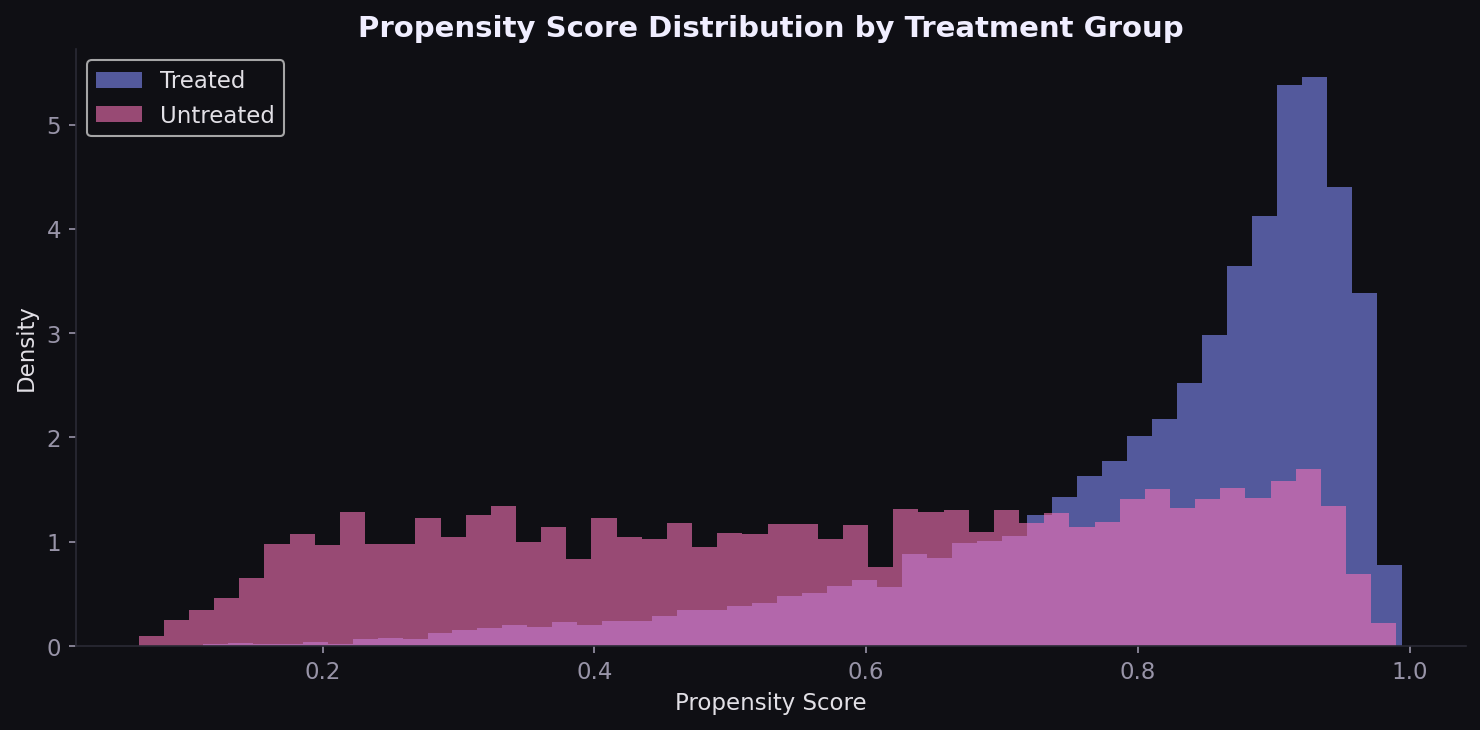

In [4]:
# PS distribution plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df.loc[df.treated==1, 'ps'], bins=50, alpha=0.6, color=INDIGO, label='Treated', density=True)
ax.hist(df.loc[df.treated==0, 'ps'], bins=50, alpha=0.6, color=PINK, label='Untreated', density=True)
ax.set_xlabel('Propensity Score')
ax.set_ylabel('Density')
ax.set_title('Propensity Score Distribution by Treatment Group', fontsize=14, fontweight='bold', color='#F0EEFF')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'ps_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. 1:1 Nearest-neighbor matching (caliper = 0.2 SD of logit PS)

In [5]:
caliper = 0.2 * df['logit_ps'].std()
print(f'Caliper: {caliper:.4f}')

treated_idx = df[df['treated'] == 1].index.values
control_idx = df[df['treated'] == 0].index.values

treated_ps = df.loc[treated_idx, 'logit_ps'].values
control_ps = df.loc[control_idx, 'logit_ps'].values

# Greedy 1:1 matching
np.random.seed(42)
np.random.shuffle(treated_idx)

matched_treated = []
matched_control = []
used_controls = set()

for t_idx in treated_idx:
    t_ps = df.loc[t_idx, 'logit_ps']
    dists = np.abs(control_ps - t_ps)
    
    sorted_order = np.argsort(dists)
    for j in sorted_order:
        c_idx = control_idx[j]
        if c_idx not in used_controls and dists[j] <= caliper:
            matched_treated.append(t_idx)
            matched_control.append(c_idx)
            used_controls.add(c_idx)
            break

matched_ids = matched_treated + matched_control
matched = df.loc[matched_ids].copy()
print(f'Matched pairs: {len(matched_treated):,}')
print(f'Matched sample: {len(matched):,} ({len(matched_treated):,} treated + {len(matched_control):,} control)')

Caliper: 0.2477


Matched pairs: 3,481
Matched sample: 6,962 (3,481 treated + 3,481 control)


---
## 3. IPTW weights

In [6]:
# ATE weights: treated get 1/PS, untreated get 1/(1-PS)
df['iptw'] = np.where(df['treated'] == 1, 1 / df['ps'], 1 / (1 - df['ps']))

# Trim extreme weights at 99th percentile
cap = df['iptw'].quantile(0.99)
df['iptw_trimmed'] = df['iptw'].clip(upper=cap)

print(f'IPTW range (raw): {df.iptw.min():.2f} - {df.iptw.max():.2f}')
print(f'IPTW range (trimmed): {df.iptw_trimmed.min():.2f} - {df.iptw_trimmed.max():.2f}')
print(f'Trimmed at: {cap:.2f}')

IPTW range (raw): 1.01 - 103.04
IPTW range (trimmed): 1.01 - 15.36
Trimmed at: 15.36


---
## 4. Covariate balance: SMD before and after

In [7]:
def calc_smd(data, covs, treatment_col, weight_col=None):
    smds = {}
    for cov in covs:
        t = data[data[treatment_col] == 1]
        c = data[data[treatment_col] == 0]
        if weight_col:
            wt, wc = t[weight_col], c[weight_col]
            mean_t = np.average(t[cov], weights=wt)
            mean_c = np.average(c[cov], weights=wc)
            var_t = np.average((t[cov] - mean_t)**2, weights=wt)
            var_c = np.average((c[cov] - mean_c)**2, weights=wc)
        else:
            mean_t, mean_c = t[cov].mean(), c[cov].mean()
            var_t, var_c = t[cov].var(), c[cov].var()
        pooled_sd = np.sqrt((var_t + var_c) / 2)
        smds[cov] = abs(mean_t - mean_c) / pooled_sd if pooled_sd > 0 else 0
    return pd.Series(smds)

numeric_covs = ['age', 'female', 'education', 'pir', 'bmi', 'diabetes', 'smoker', 'hba1c']

smd_before = calc_smd(df, numeric_covs, 'treated')
smd_matched = calc_smd(matched, numeric_covs, 'treated')
smd_iptw = calc_smd(df, numeric_covs, 'treated', 'iptw_trimmed')

balance = pd.DataFrame({'Unadjusted': smd_before, 'Matched': smd_matched, 'IPTW': smd_iptw}).round(4)
balance

,Unadjusted,Matched,IPTW
age,1.0199,0.0079,0.0245
female,0.1256,0.0172,0.0149
education,0.0843,0.0169,0.0203
pir,0.0747,0.0116,0.0046
bmi,0.1019,0.0057,0.0472
diabetes,0.4755,0.0601,0.0703
smoker,0.0599,0.0052,0.0038
hba1c,0.3374,0.0025,0.0316


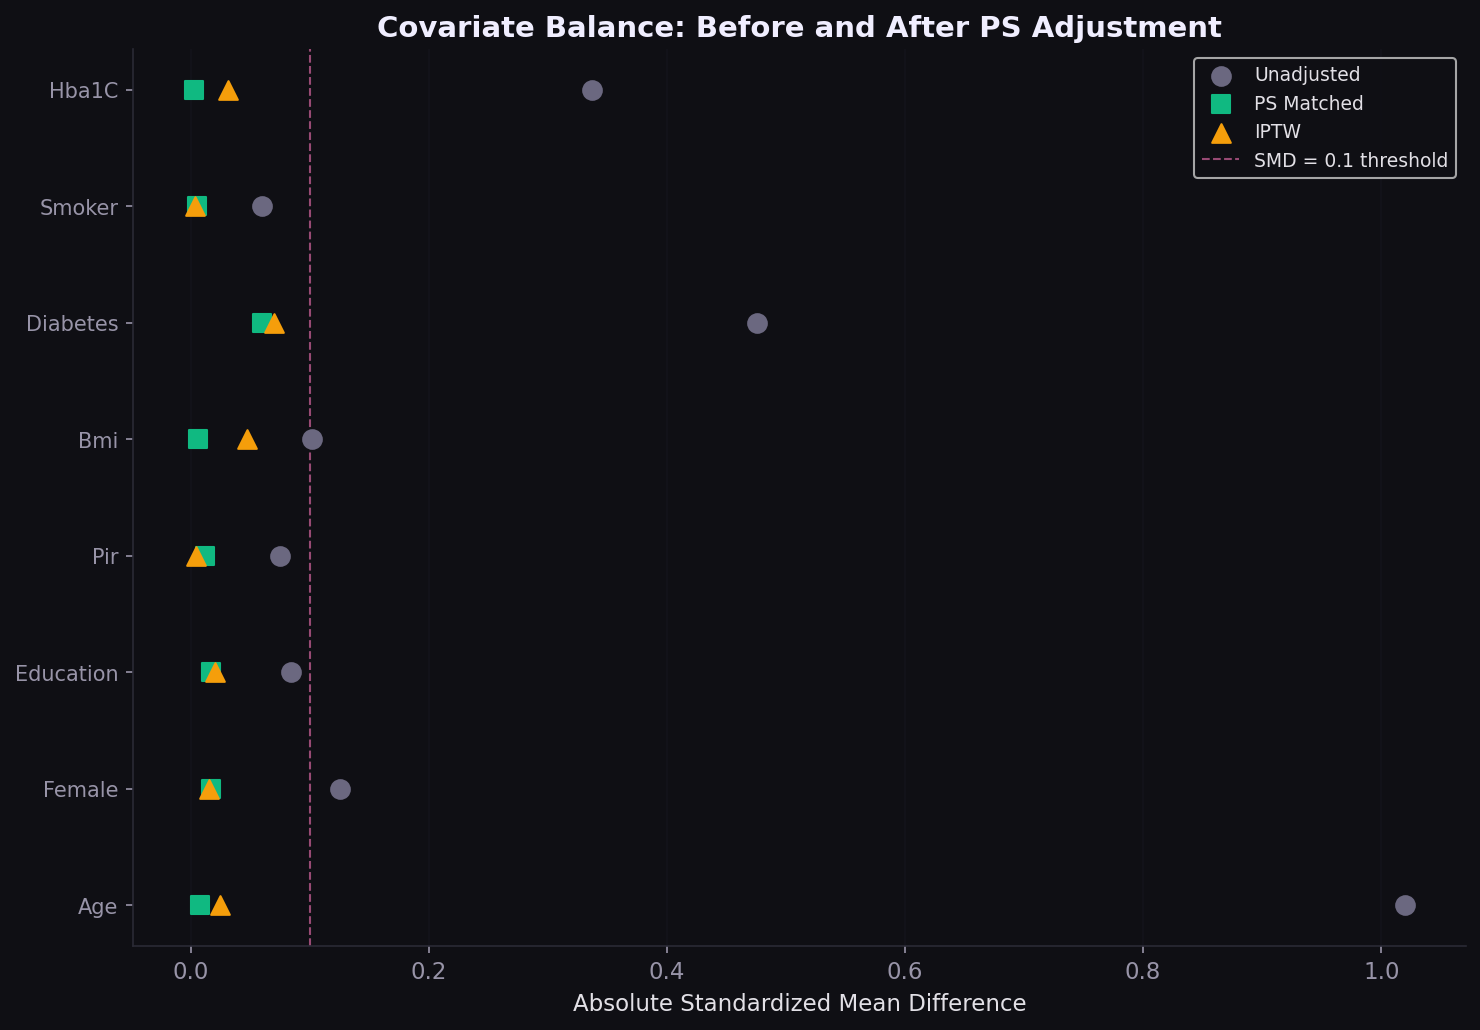

In [8]:
# Love plot
fig, ax = plt.subplots(figsize=(10, 7))
y_pos = range(len(balance))
labels = [c.replace('_', ' ').title() for c in balance.index]

ax.scatter(balance['Unadjusted'], y_pos, color='#6B6880', s=80, marker='o', label='Unadjusted', zorder=3)
ax.scatter(balance['Matched'], y_pos, color=GREEN, s=80, marker='s', label='PS Matched', zorder=3)
ax.scatter(balance['IPTW'], y_pos, color=AMBER, s=80, marker='^', label='IPTW', zorder=3)

ax.axvline(x=0.1, color=PINK, linestyle='--', alpha=0.6, linewidth=1, label='SMD = 0.1 threshold')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Absolute Standardized Mean Difference')
ax.set_title('Covariate Balance: Before and After PS Adjustment', fontsize=14, fontweight='bold', color='#F0EEFF')
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'love_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Save matched and IPTW datasets

In [9]:
matched.to_csv(PROCESSED / 'matched_cohort.csv', index=False)
df.to_csv(PROCESSED / 'iptw_cohort.csv', index=False)

for f in PROCESSED.glob('*.csv'):
    print(f'{f.name}: {f.stat().st_size / 1e6:.1f} MB')

matched_cohort.csv: 1.0 MB
iptw_cohort.csv: 3.2 MB
hypertension_cohort.csv: 1.4 MB
